week 2,phase 3 for all datasets


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_borr=pd.read_csv("C:/Users/admin/Downloads/datasets/borrowing_funding_dataset.csv")

In [2]:
df_borr.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   borrowing_id         200000 non-null  int64  
 1   funding_source       200000 non-null  str    
 2   cost_of_funds        200000 non-null  float64
 3   maturity_bucket      200000 non-null  str    
 4   interest_reset_type  200000 non-null  str    
 5   borrowing_amount     200000 non-null  int64  
 6   rollover_risk_score  200000 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 14.1 MB


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_macro=pd.read_csv("C:/Users/admin/Downloads/datasets/market_macro_dataset.csv")

In [4]:
df_macro.info()

<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             600000 non-null  str    
 1   repo_rate        600000 non-null  float64
 2   gsec_10y         600000 non-null  float64
 3   cp_rate          600000 non-null  float64
 4   inflation_cpi    600000 non-null  float64
 5   liquidity_index  600000 non-null  float64
 6   usd_inr          600000 non-null  float64
dtypes: float64(6), str(1)
memory usage: 37.8 MB


In [6]:
df_borr.columns
df_macro.columns

Index(['date', 'repo_rate', 'gsec_10y', 'cp_rate', 'inflation_cpi',
       'liquidity_index', 'usd_inr'],
      dtype='str')

In [7]:
df_borr.columns

Index(['borrowing_id', 'funding_source', 'cost_of_funds', 'maturity_bucket',
       'interest_reset_type', 'borrowing_amount', 'rollover_risk_score'],
      dtype='str')

In [10]:
df_cash=pd.read_csv("C:/Users/admin/Downloads/datasets/daily_cashflow_dataset.csv")

In [11]:
df_loan=pd.read_csv("C:/Users/admin/Downloads/datasets/loan_portfolio_dataset.csv")

In [12]:
df_borr.columns

Index(['borrowing_id', 'funding_source', 'cost_of_funds', 'maturity_bucket',
       'interest_reset_type', 'borrowing_amount', 'rollover_risk_score'],
      dtype='str')

In [13]:
df_macro.columns

Index(['date', 'repo_rate', 'gsec_10y', 'cp_rate', 'inflation_cpi',
       'liquidity_index', 'usd_inr'],
      dtype='str')

In [14]:
df_cash.columns

Index(['date', 'inflow_type', 'outflow_type', 'expected_amount',
       'actual_amount', 'variance'],
      dtype='str')

In [15]:
df_loan.columns

Index(['loan_id', 'customer_segment', 'sanction_amount',
       'outstanding_principal', 'interest_rate', 'repricing_frequency',
       'prepayment_option', 'collateral_type', 'region', 'tenure_months'],
      dtype='str')

In [17]:
df_cash_variance_liquidity = df_cash.groupby('date')['variance'].mean().reset_index()

df_cash_variance_liquidity.head()

,date,variance
0,2022-01-01,295651.427119
1,2022-01-02,-89410.959707
2,2022-01-03,-21472.175097
3,2022-01-04,87755.584416
4,2022-01-05,235501.432331


In [39]:
df_borr_agg_roll = df_borr[['cost_of_funds', 'borrowing_amount', 'rollover_risk_score']]

df_borr_agg_roll

,cost_of_funds,borrowing_amount,rollover_risk_score
0,9.07,8928717,0.9472
1,8.69,31344155,0.2102
2,7.46,21925818,0.3430
3,8.45,11737224,0.9142
4,7.56,43446206,0.6087
...,...,...,...
199995,5.65,18949628,0.6378
199996,9.38,10606928,0.0016
199997,9.39,33548319,0.5925
199998,5.33,44607877,0.0913


In [40]:
df_borr_expanded = pd.concat([df_borr_agg_roll,df_cash_variance_liquidity])

In [41]:
df_borr_expanded

,cost_of_funds,borrowing_amount,rollover_risk_score,date,variance
0,9.07,8928717.0,0.9472,NaN,NaN
1,8.69,31344155.0,0.2102,NaN,NaN
2,7.46,21925818.0,0.3430,NaN,NaN
3,8.45,11737224.0,0.9142,NaN,NaN
4,7.56,43446206.0,0.6087,NaN,NaN
...,...,...,...,...,...
1090,NaN,NaN,NaN,2024-12-26,-58931.988462
1091,NaN,NaN,NaN,2024-12-27,-49361.027237
1092,NaN,NaN,NaN,2024-12-28,-3121.077821
1093,NaN,NaN,NaN,2024-12-29,-10081.164336


In [42]:
df_final = df_cash_variance_liquidity + df_borr_expanded

df_final.head()

,borrowing_amount,cost_of_funds,date,rollover_risk_score,variance
0,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,2022-01-012022-01-01,NaN,591302.854237
1,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2022-01-022022-01-02,NaN,-178821.919414
2,NaN,NaN,NaN,NaN,NaN


In [46]:
df_selected = df_final[['borrowing_amount','cost_of_funds','rollover_risk_score','variance','date']] 

df_final.head()

,borrowing_amount,cost_of_funds,date,rollover_risk_score,variance
0,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,2022-01-012022-01-01,NaN,591302.854237
1,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2022-01-022022-01-02,NaN,-178821.919414
2,NaN,NaN,NaN,NaN,NaN


In [47]:
df_selected = df_final.select_dtypes(include=['int64', 'float64'])

corr_matrix = df_selected.corr()

corr_matrix

,borrowing_amount,cost_of_funds,rollover_risk_score,variance
borrowing_amount,NaN,NaN,NaN,NaN
cost_of_funds,NaN,NaN,NaN,NaN
rollover_risk_score,NaN,NaN,NaN,NaN
variance,NaN,NaN,NaN,1.0


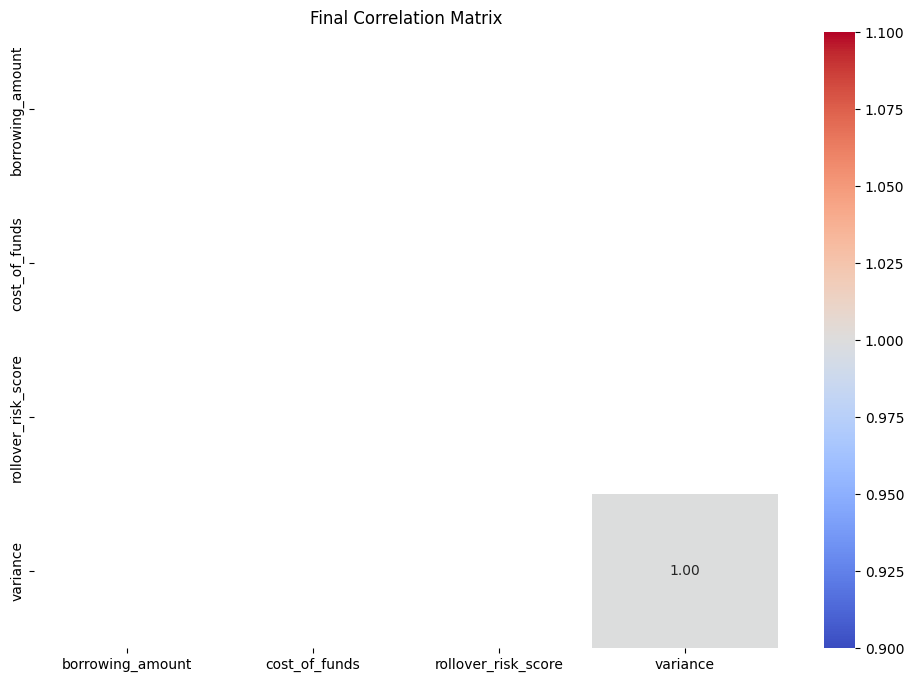

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Final Correlation Matrix")
plt.show()

In [50]:
corr_matrix.info()

<class 'pandas.DataFrame'>
Index: 4 entries, borrowing_amount to variance
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   borrowing_amount     0 non-null      float64
 1   cost_of_funds        0 non-null      float64
 2   rollover_risk_score  0 non-null      float64
 3   variance             1 non-null      float64
dtypes: float64(4)
memory usage: 389.0 bytes
